In [1]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import smplotlib
import numpy as np

In [2]:
#read the spectrum data of full disk
wavelength = np.zeros((100,25))
flux_full  = np.zeros((100,25))

for i in range(0,25):
    j=i+1
    file = open('./simu-full/'+str(j).rjust(4,'0')+'/spectrum.out','r')
    arr  = file.readlines()
    listt = []
    for n in range(3,103):
        listt = listt+arr[n].split()
    for n in range(0,100):
        wavelength[n,i] = listt[2*n]   
        flux_full[n,i]  = listt[2*n+1]   

#read the spectrum data of atmospheric model
x = np.zeros(100)
y = np.zeros(100)

file  = open('./simu-full/1000/spectrum.out','r')
arr   = file.readlines()
listt = []
for n in range(3,103):
    listt = listt+arr[n].split()
for n in range(0,100):
    x[n] = listt[2*n]
    y[n] = listt[2*n+1]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


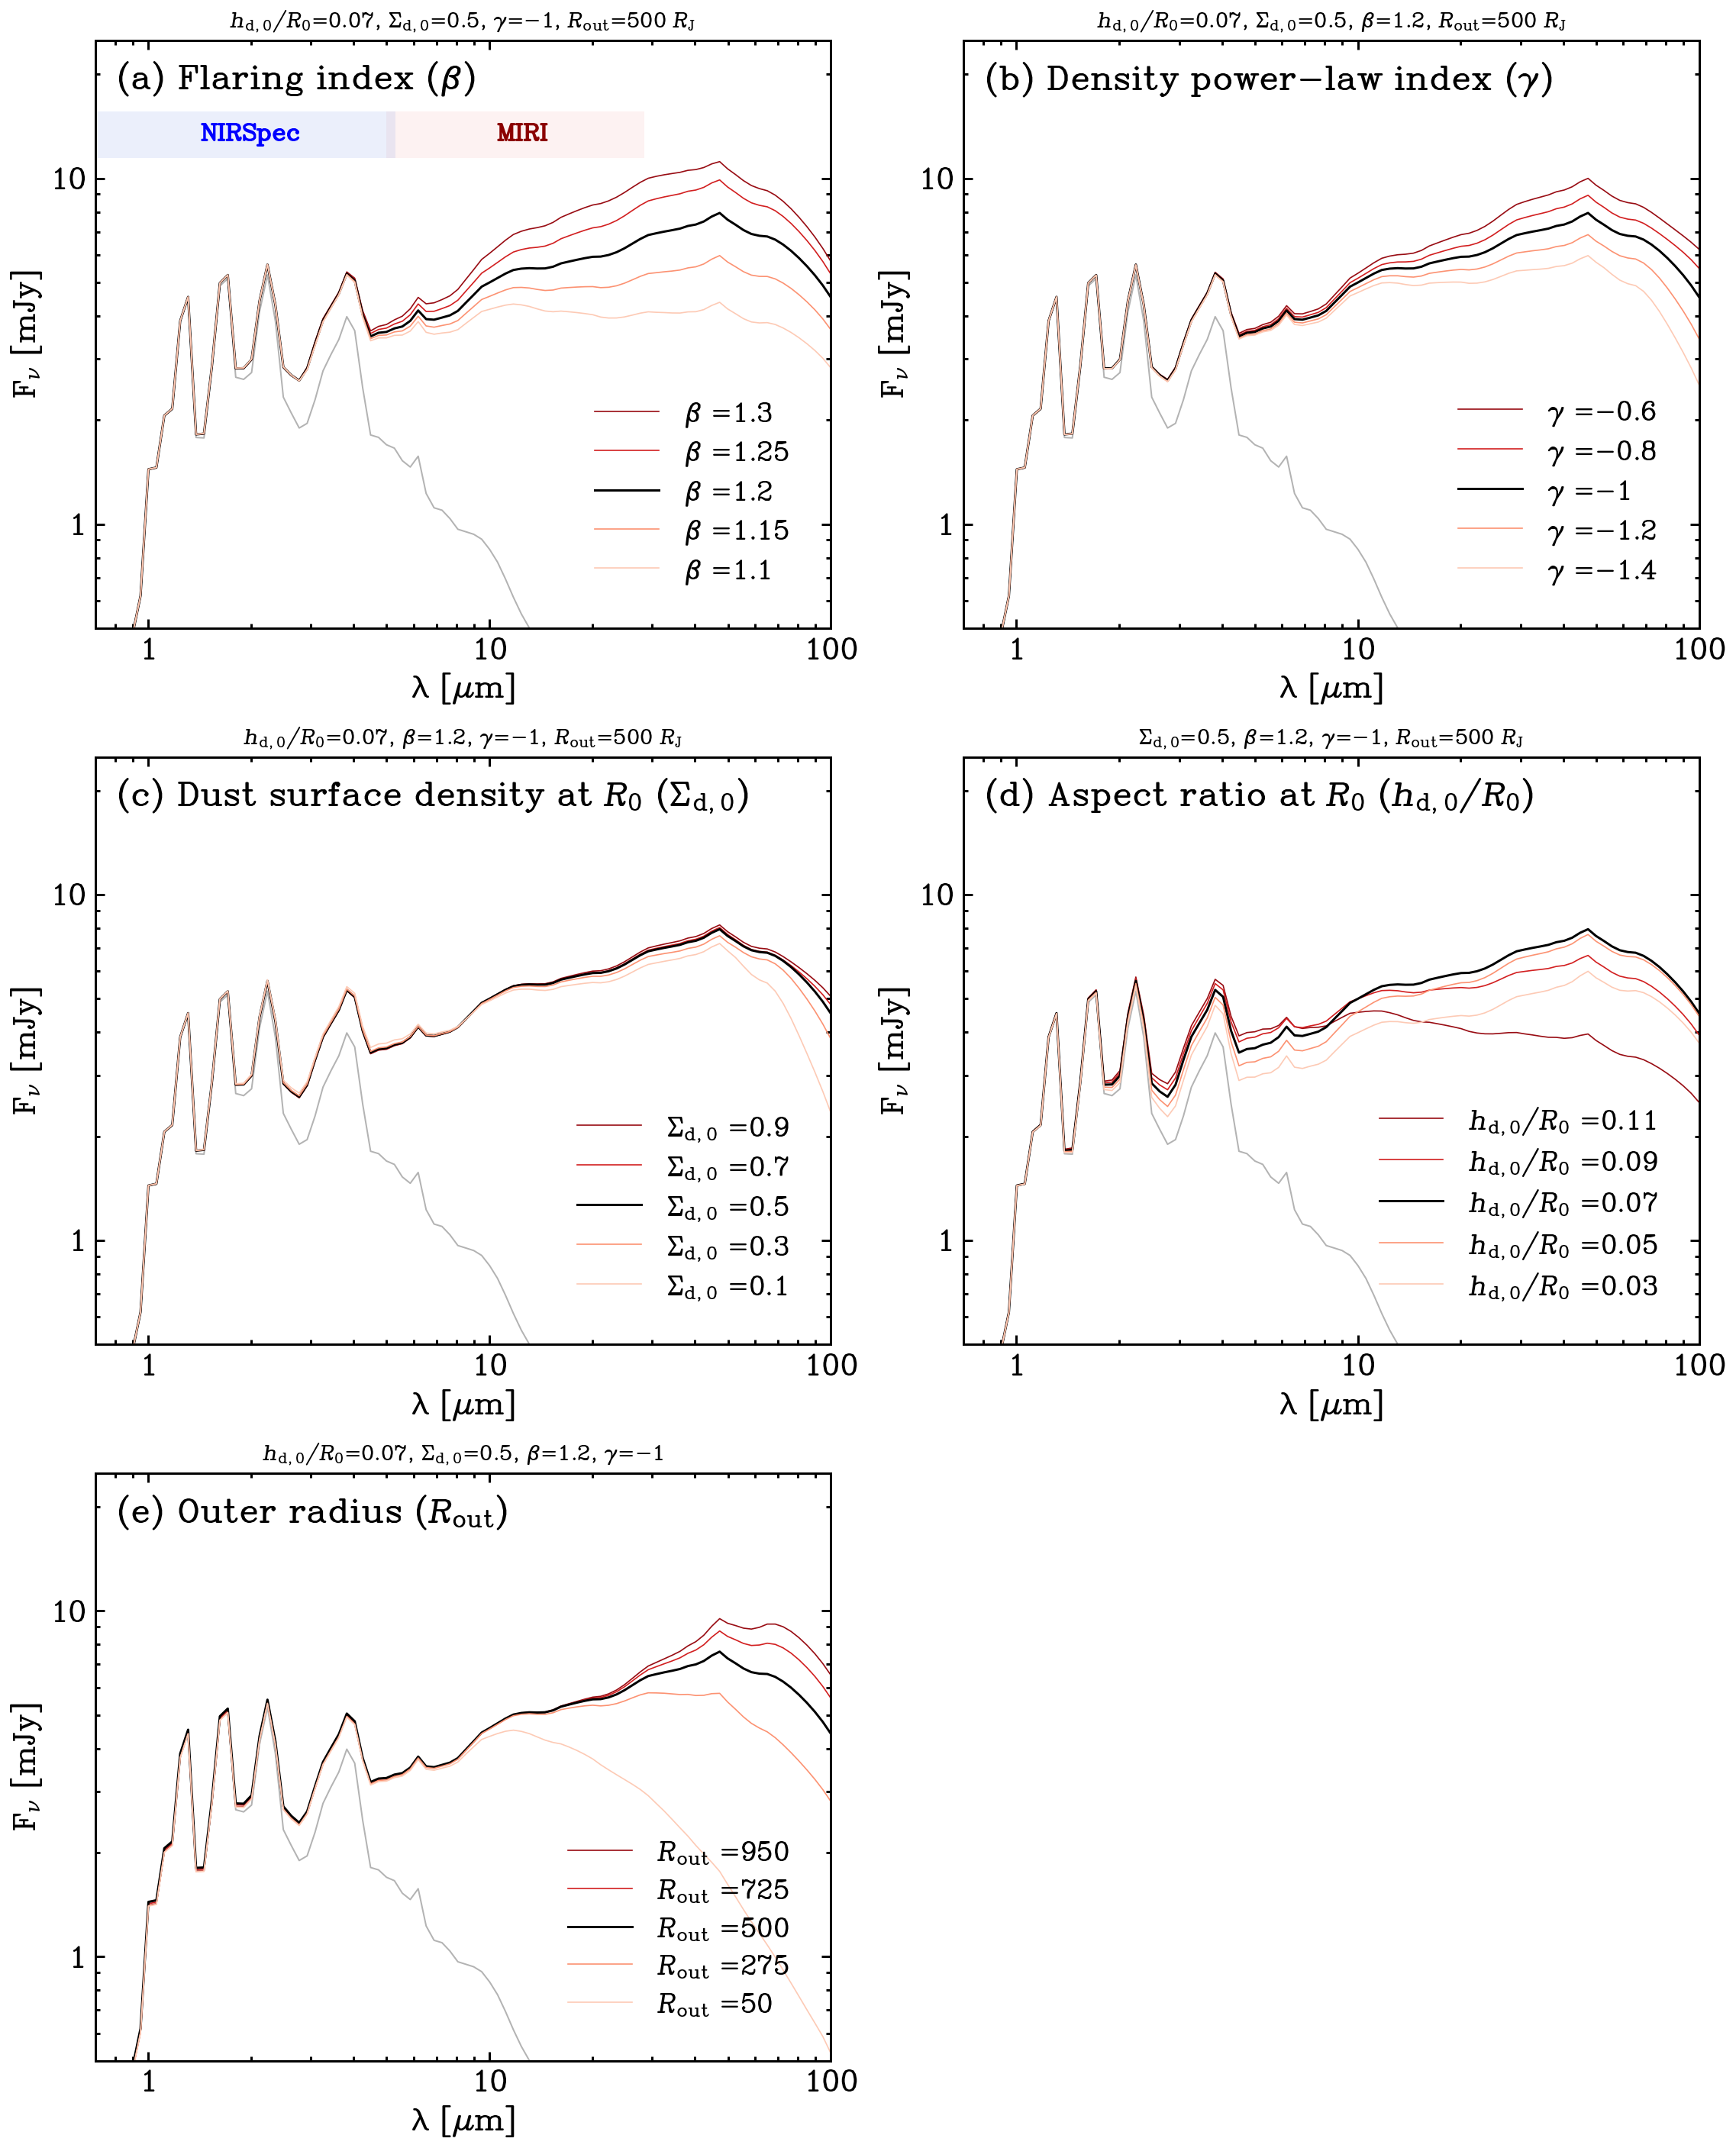

In [3]:
fig,axes = plt.subplots(nrows=3, ncols=2, figsize=(20,24.5))

h_over_r = [0.11, 0.09, 0.07, 0.05, 0.03]
Sigma0   = [0.9, 0.7, 0.5, 0.3, 0.1]
hrslope  = [1.3, 1.25, 1.2, 1.15, 1.1]
dslope   = [-0.6, -0.8, -1, -1.2, -1.4]
rout     = [950, 725, 500, 275, 50]
distance = 50 # unit: pc

color_list = plt.cm.Reds(np.linspace(0.9, 0.2, 5))

#panel 1
ax=axes[0,0]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(0,5):
    if color_num == 2: #fiducial model
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$\beta$ ='+str(hrslope[i]), linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else: #other models
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$\beta$ ='+str(hrslope[i]), linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1

ax.axvspan(5, 28.5, ymin=0.80, ymax=0.88, color='lightcoral', alpha=0.1, lw=0)
ax.axvspan(0.6, 5.3, ymin=0.80, ymax=0.88, color='royalblue', alpha=0.1, lw=0)
ax.text(2, 0.84, 'NIRSpec', color='blue', fontsize=24, fontweight='bold', ha='center', va='center', transform=ax.get_xaxis_transform())
ax.text(12.5, 0.84, 'MIRI', color='darkred', fontsize=24, fontweight='bold', ha='center', va='center', transform=ax.get_xaxis_transform())

ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$',fontsize= 20)
ax.text(0.8,1.8e-25,r'(a) Flaring index ($\beta$)',fontsize=32)

#panel 2
ax=axes[0,1]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(5,10):
    if color_num == 2: #fiducial model
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$\gamma$ ='+str(dslope[i-5]), linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else: #other models
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$\gamma$ ='+str(dslope[i-5]), linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1
            
ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $R_\mathrm{out}$=500 $R_\mathrm{J}$',fontsize=20)
ax.text(0.8,1.8e-25,r'(b) Density power-law index ($\gamma$)',fontsize=32)

#panel 3
ax=axes[1,0]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(10,15):
    if color_num == 2: #fiducial model
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$\Sigma_\mathrm{d,0}$ ='+str(Sigma0[i-10]), linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else: #other models
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$\Sigma_\mathrm{d,0}$ ='+str(Sigma0[i-10]), linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1
              
ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$',fontsize=20)
ax.text(0.8,1.8e-25,r'(c) Dust surface density at $R_0$ ($\Sigma_\mathrm{d,0}$)',fontsize=32)

#panel 4
ax=axes[1,1]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(15,20):
    if color_num == 2: #fiducial model
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$h_\mathrm{d,0}/R_0$ ='+str(h_over_r[i-15]), linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else: #other models
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$h_\mathrm{d,0}/R_0$ ='+str(h_over_r[i-15]), linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1

ax.set_title(r'$\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$',fontsize=20)
ax.text(0.8,1.8e-25,r'(d) Aspect ratio at $R_0$ ($h_\mathrm{d,0}/R_0$)',fontsize=32)

#panel 5
ax=axes[2,0]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(20,25):
    if color_num == 2: #fiducial model
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$R_\mathrm{out}$ ='+str(rout[i-20]), linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else: #other models
        ax.plot(wavelength[:,i],(flux_full[:,i])/distance**2, label=r'$R_\mathrm{out}$ ='+str(rout[i-20]), linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1
        
ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1',fontsize= 20)
ax.text(0.8,1.8e-25,r'(e) Outer radius ($R_\mathrm{out}$)',fontsize=32)

#common setup
for idx, ax in enumerate(axes.flat, start=1):
    ax.set_xlim(0.7,100)
    ax.set_ylim(5e-27,2.5e-25)
    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel(r'$\lambda$ [$\mu$m]',fontsize= 28)
    ax.set_ylabel(r"F$_\nu$ [mJy]",fontsize= 28)

    ax.set_xticks([1e0,1e1,1e2],[r'1',r'10',r'100'],fontsize= 28)
    ax.set_yticks([1e-26,1e-25],[r'1',r'10'],fontsize= 28)

    ax.tick_params(axis='both', direction='in', width=1.8, which='major',top=True, right=True)
    ax.tick_params(axis='both', direction='in', width=1.8, which='minor',top=True, right=True)
    ax.spines['left'].set_linewidth(1.8)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['right'].set_linewidth(1.8)
    ax.spines['top'].set_linewidth(1.8)
    
    ax.legend(fontsize= 25,loc='lower right')

plt.tight_layout(pad=3.0,w_pad=1.0, h_pad=1.0)
fig.delaxes(axes[2, 1])
plt.show()

In [4]:
#read the spectrum data of pre-transitional disk
wavelength = np.zeros((100,13))
flux_pre   = np.zeros((100,13))

for i in range(0,13):
    j=i+1
    file = open('./simu-pre-transitional/'+str(j).rjust(4,'0')+'/spectrum.out','r')
    arr  = file.readlines()
    listt = []
    for n in range(3,103):
        listt = listt+arr[n].split()
    for n in range(0,100):
        wavelength[n,i] = listt[2*n]   
        flux_pre[n,i]   = listt[2*n+1]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


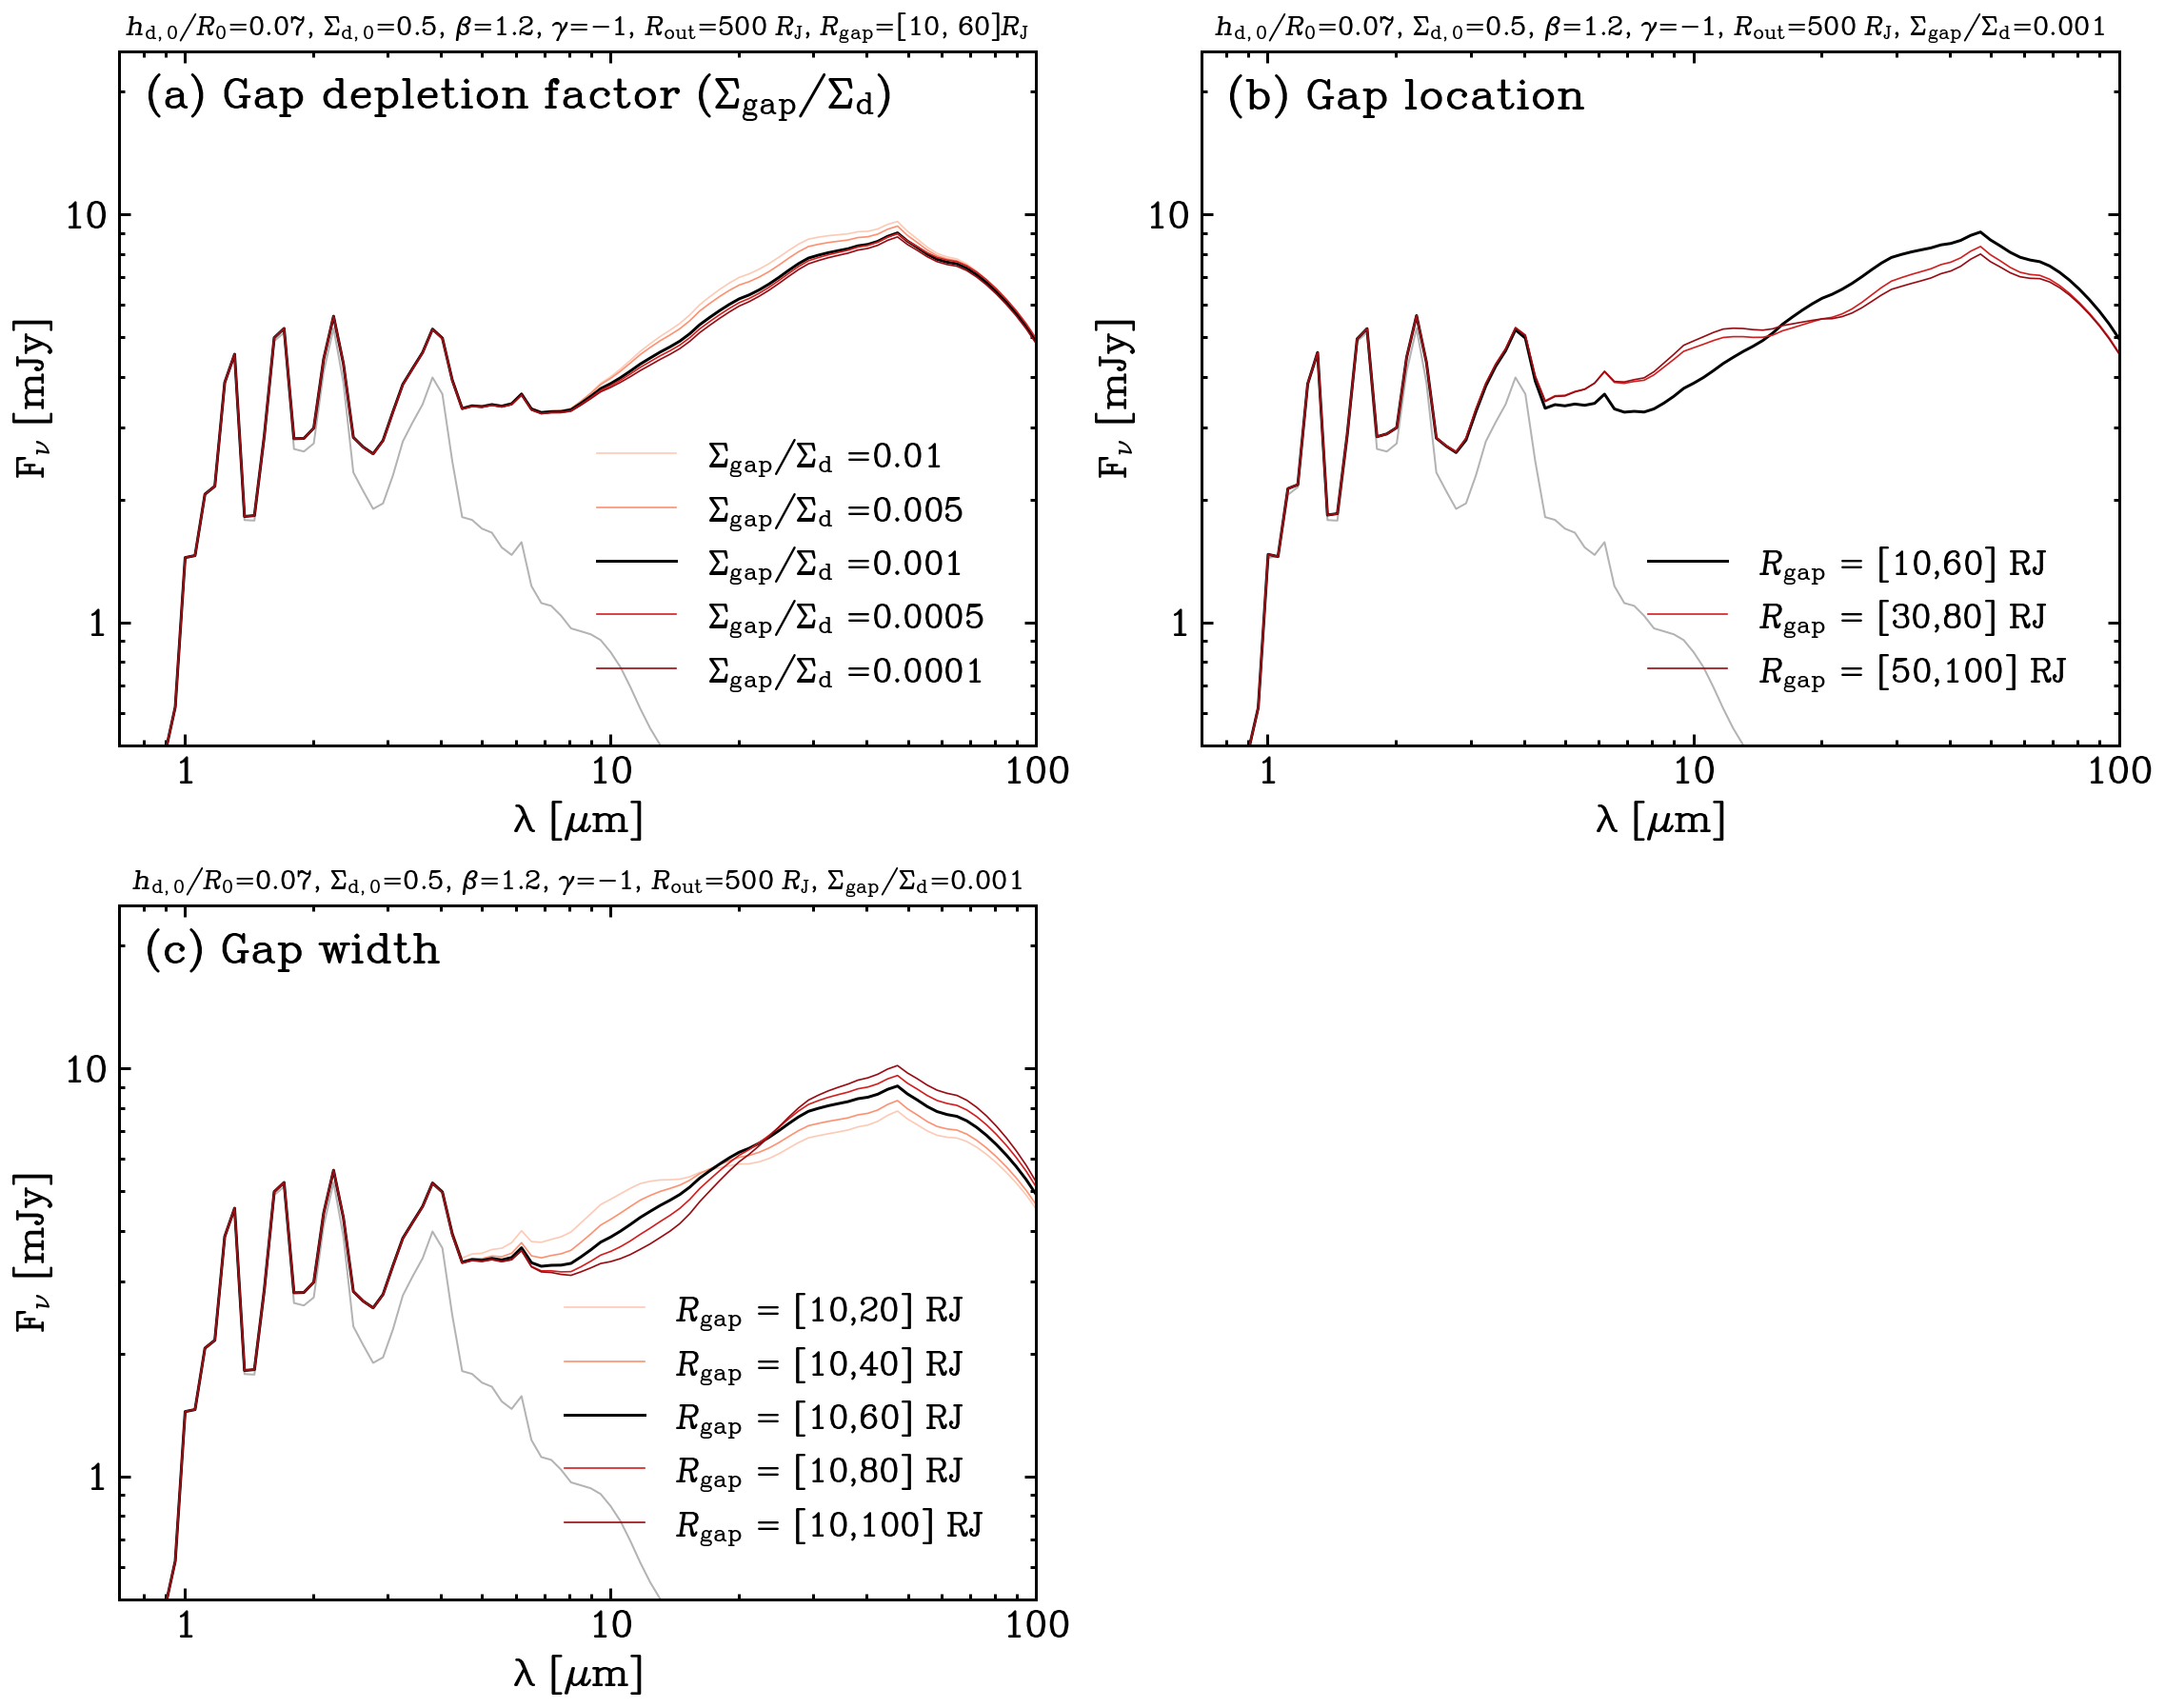

In [5]:
fig,axes = plt.subplots(nrows=2, ncols=2, figsize=(20,16))

dep_list  = [1e-2,5e-3,1e-3,5e-4,1e-4]
gap_list  = [10,30,50]
gap_list2 = [20,40,60,80,100]
distance  = 50

color_list = plt.cm.Reds(np.linspace(0.2, 0.9, 5))

#panel 1
ax=axes[0,0]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(0,5):
    j=i
    if color_num==2:
        ax.plot(wavelength[:,i],(flux_pre[:,j])/50**2, label=r'$\Sigma_{\mathrm{gap}}/\Sigma_\mathrm{d}$ ='+str(dep_list[i]), linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else:
        ax.plot(wavelength[:,i],(flux_pre[:,j])/50**2, label=r'$\Sigma_{\mathrm{gap}}/\Sigma_\mathrm{d}$ ='+str(dep_list[i]), linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1

ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$, $R_\mathrm{gap}$=[10, 60]$R_\mathrm{J}$',fontsize= 20)
ax.text(0.8,1.8e-25,r'(a) Gap depletion factor ($\Sigma_{\mathrm{gap}}/\Sigma_\mathrm{d}$)',fontsize=32)

#panel 2
ax=axes[0,1]
ax.plot(x,y/distance**2, color='0.7')

ax.plot(wavelength[:,5],(flux_pre[:,5])/distance**2, label=r'$R_\mathrm{gap}$ = ['+str(gap_list[0])+','+str(gap_list[0]+50)+'] RJ', linestyle='-',color='k',linewidth=1.8)
ax.plot(wavelength[:,6],(flux_pre[:,6])/distance**2, label=r'$R_\mathrm{gap}$ = ['+str(gap_list[1])+','+str(gap_list[1]+50)+'] RJ', linestyle='-',color=color_list[3],linewidth=1)
ax.plot(wavelength[:,7],(flux_pre[:,7])/distance**2, label=r'$R_\mathrm{gap}$ = ['+str(gap_list[2])+','+str(gap_list[2]+50)+'] RJ', linestyle='-',color=color_list[4],linewidth=1)

ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$, $\Sigma_{\mathrm{gap}}/\Sigma_\mathrm{d}$=0.001',fontsize= 20)
ax.text(0.8,1.8e-25,'(b) Gap location',fontsize=32)

#panel 3
ax=axes[1,0]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(8,13):
    j = i-8
    if color_num==2:
        ax.plot(wavelength[:,i],(flux_pre[:,i])/50**2, label=r'$R_\mathrm{gap}$ = [10,'+str(gap_list2[j])+'] RJ', linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else:
        ax.plot(wavelength[:,i],(flux_pre[:,i])/50**2, label=r'$R_\mathrm{gap}$ = [10,'+str(gap_list2[j])+'] RJ', linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1

ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$, $\Sigma_{\mathrm{gap}}/\Sigma_\mathrm{d}$=0.001',fontsize= 20)
ax.text(0.8,1.8e-25,'(c) Gap width',fontsize=32)

#common setup
for idx, ax in enumerate(axes.flat, start=1):
    ax.set_xlim(0.7,100)
    ax.set_ylim(5e-27,2.5e-25)
    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel(r'$\lambda$ [$\mu$m]',fontsize= 28)
    ax.set_ylabel(r"F$_\nu$ [mJy]",fontsize= 28)

    ax.set_xticks([1e0,1e1,1e2],[r'1',r'10',r'100'],fontsize= 28)
    ax.set_yticks([1e-26,1e-25],[r'1',r'10'],fontsize= 28)

    ax.tick_params(axis='both', direction='in', width=1.8, which='major',top=True, right=True)
    ax.tick_params(axis='both', direction='in', width=1.8, which='minor',top=True, right=True)
    ax.spines['left'].set_linewidth(1.8)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['right'].set_linewidth(1.8)
    ax.spines['top'].set_linewidth(1.8)
    
    ax.legend(fontsize= 25,loc='lower right')

plt.tight_layout(pad=3.0,w_pad=1.0, h_pad=1.0)
fig.delaxes(axes[1, 1])
plt.show()

In [6]:
#read the spectrum data of transitional disk
wavelength = np.zeros((100,15))
flux_tran  = np.zeros((100,15))

for i in range(0,15):
    j=i+1
    file = open('./simu-transitional/'+str(j).rjust(4,'0')+'/spectrum.out','r')
    arr  = file.readlines()
    listt = []
    for n in range(3,103):
        listt = listt+arr[n].split()
    for n in range(0,100):
        wavelength[n,i]  = listt[2*n]   
        flux_tran[n,i]   = listt[2*n+1]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


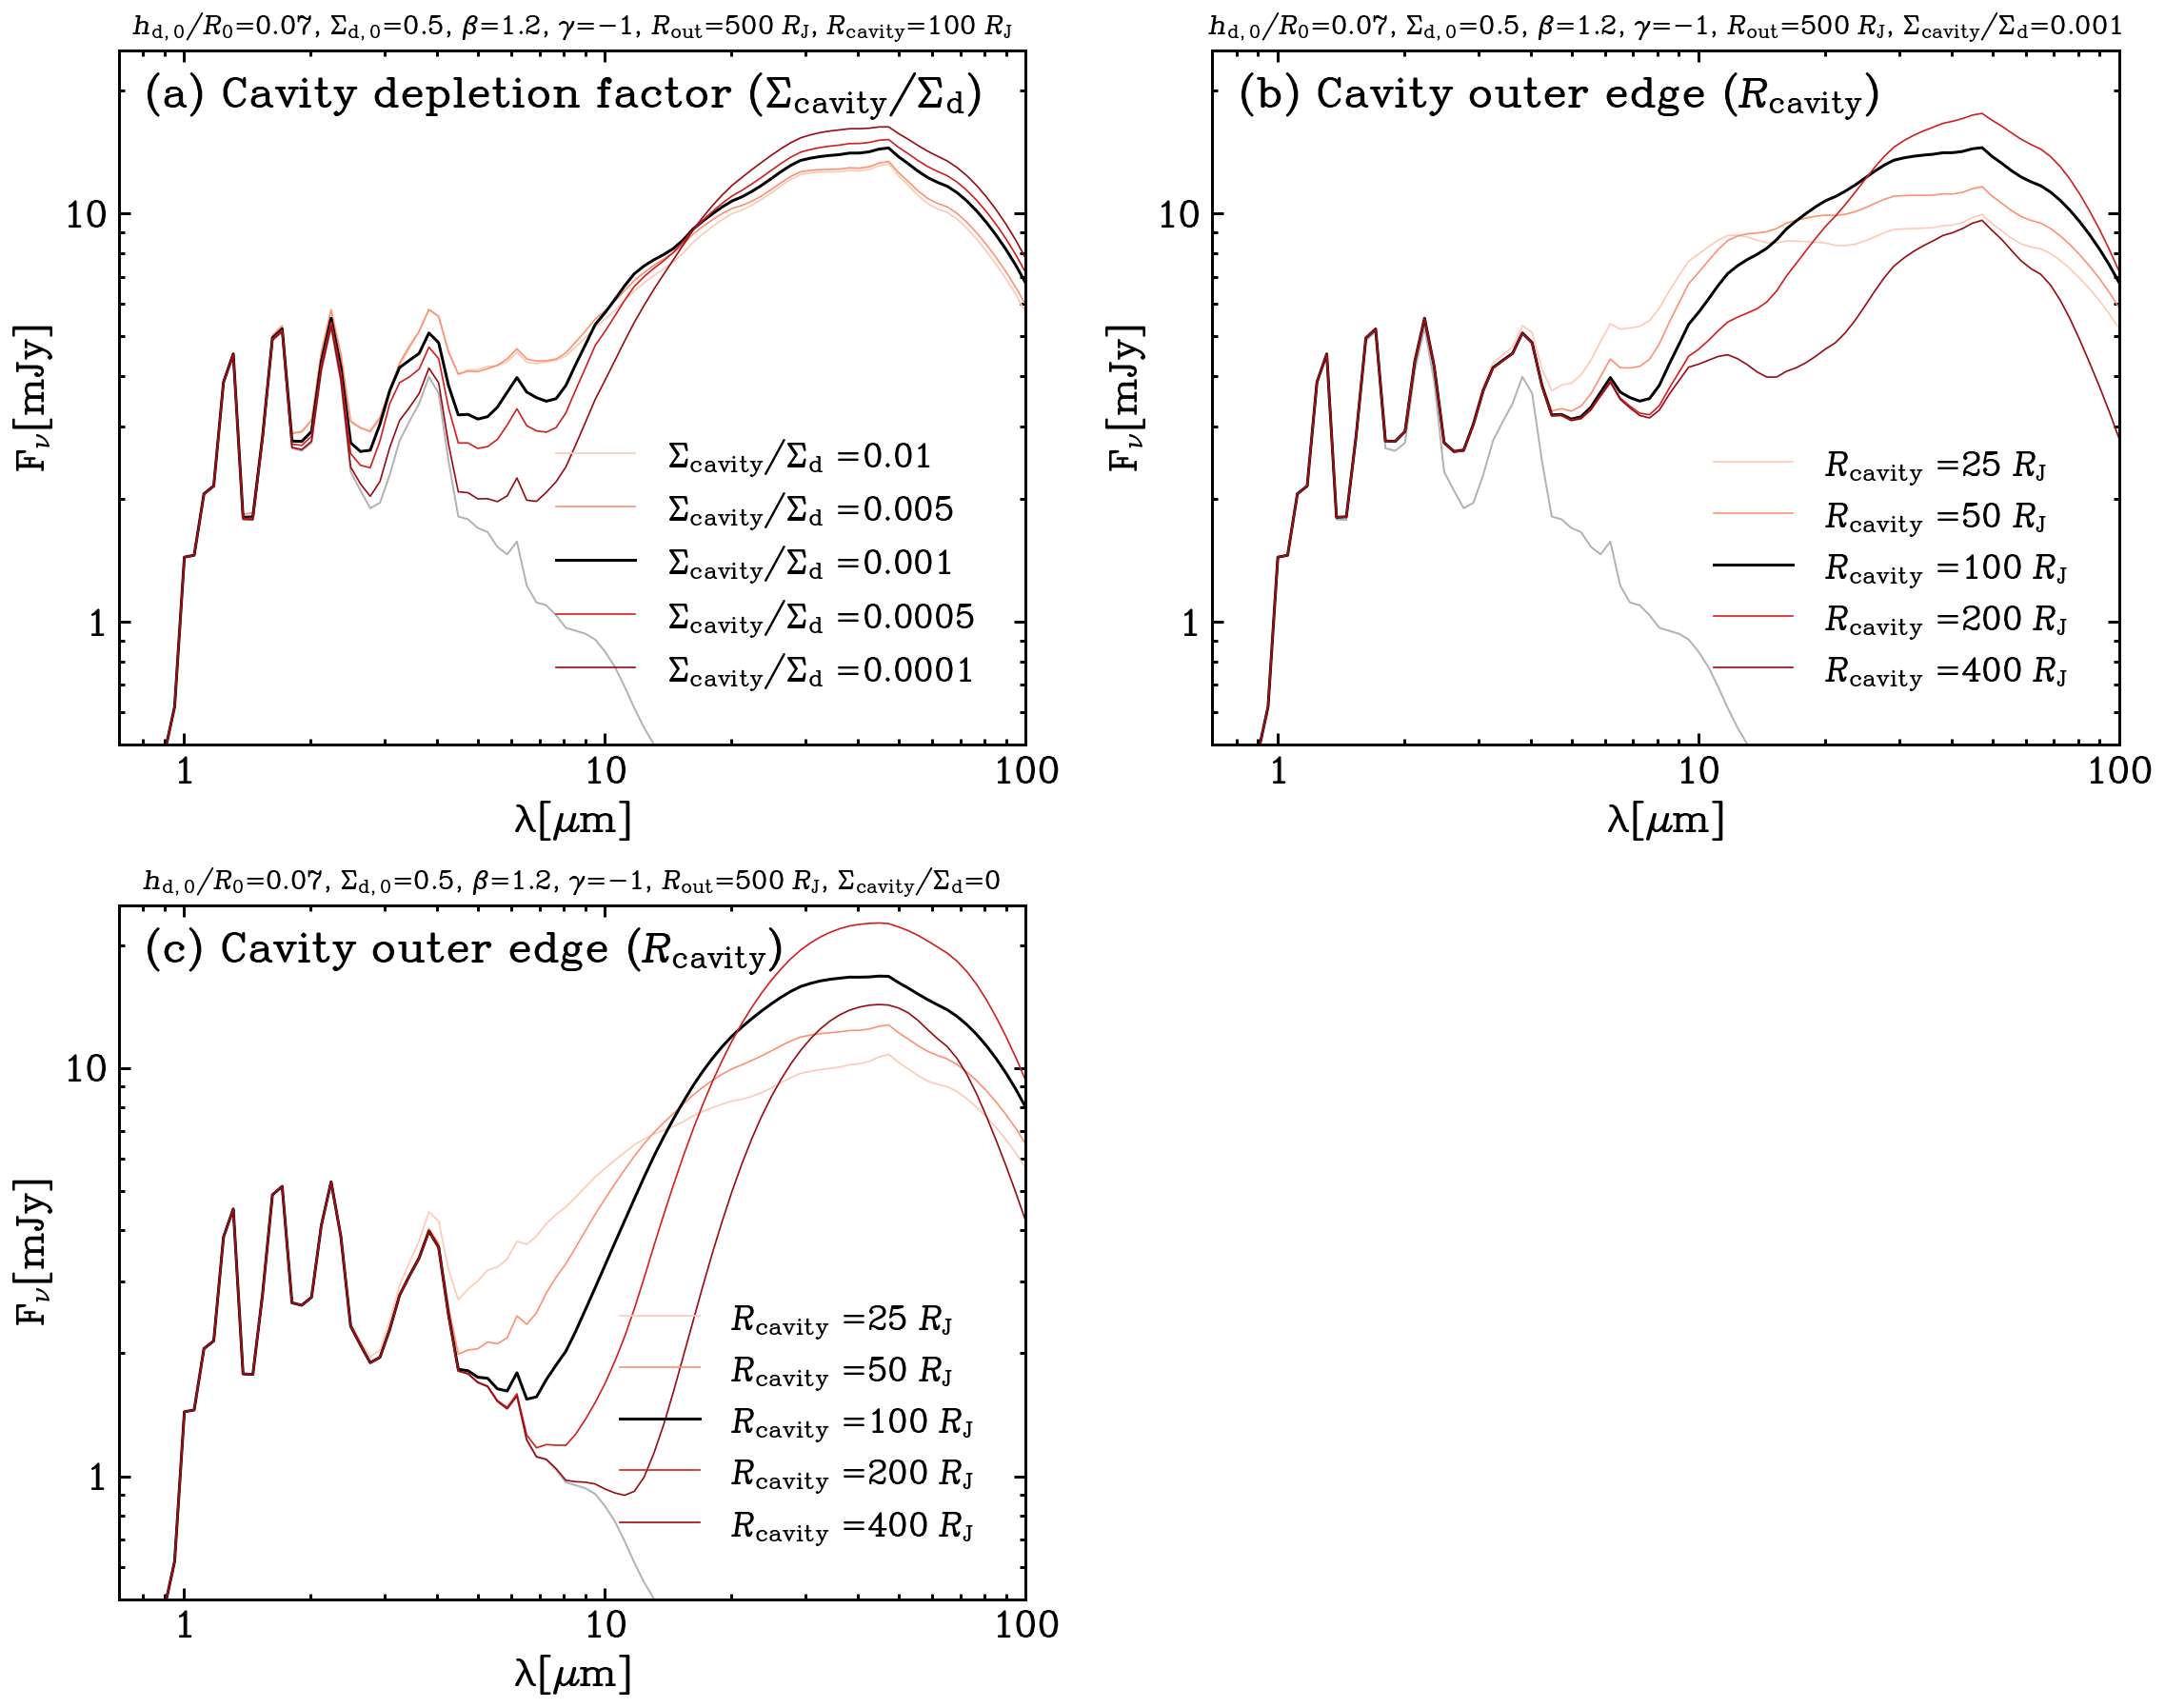

In [7]:
fig,axes = plt.subplots(nrows=2, ncols=2, figsize=(20,16))

dep_list = [1e-2,5e-3,1e-3,5e-4,1e-4]
cav_list = [25,50,100,200,400]
distance = 50

color_list = plt.cm.Reds(np.linspace(0.2, 0.9, 5))

#panel 1
ax=axes[0,0]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(0,5):
    if color_num == 2:
        ax.plot(wavelength[:,i],(flux_tran[:,i])/distance**2, label=r'$\Sigma_{\mathrm{cavity}}/\Sigma_\mathrm{d}$ ='+str(dep_list[i]), linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else:
        ax.plot(wavelength[:,i],(flux_tran[:,i])/distance**2, label=r'$\Sigma_{\mathrm{cavity}}/\Sigma_\mathrm{d}$ ='+str(dep_list[i]), linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1

ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$, $R_\mathrm{cavity}$=100 $R_\mathrm{J}$',fontsize= 20)
ax.text(0.8,1.8e-25,r'(a) Cavity depletion factor ($\Sigma_{\mathrm{cavity}}/\Sigma_\mathrm{d}$)',fontsize=32)

#panel 2
ax=axes[0,1]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(5,10):
    if color_num == 2:
        ax.plot(wavelength[:,i],(flux_tran[:,i])/distance**2, label=r'$R_\mathrm{cavity}$ ='+str(cav_list[i-5])+r' $R_\mathrm{J}$', linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else:
        ax.plot(wavelength[:,i],(flux_tran[:,i])/distance**2, label=r'$R_\mathrm{cavity}$ ='+str(cav_list[i-5])+r' $R_\mathrm{J}$', linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1

ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$, $\Sigma_{\mathrm{cavity}}/\Sigma_\mathrm{d}$=0.001',fontsize= 20)
ax.text(0.8,1.8e-25,r'(b) Cavity outer edge ($R_\mathrm{cavity}$)',fontsize=32)

#panel 3
ax=axes[1,0]
color_num = 0
ax.plot(x,y/distance**2, color='0.7')

for i in range(10,15):
    if color_num == 2:
        ax.plot(wavelength[:,i],(flux_tran[:,i])/distance**2, label=r'$R_\mathrm{cavity}$ ='+str(cav_list[i-10])+r' $R_\mathrm{J}$', linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else:
        ax.plot(wavelength[:,i],(flux_tran[:,i])/distance**2, label=r'$R_\mathrm{cavity}$ ='+str(cav_list[i-10])+r' $R_\mathrm{J}$', linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1

ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$, $\Sigma_{\mathrm{cavity}}/\Sigma_\mathrm{d}$=0',fontsize= 20)
ax.text(0.8,1.8e-25,r'(c) Cavity outer edge ($R_\mathrm{cavity}$)',fontsize=32)

#common setup
for idx, ax in enumerate(axes.flat, start=1):
    ax.set_xlim(0.7,100)
    ax.set_ylim(5e-27,2.5e-25)
    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel(r'$\lambda$[$\mu$m]',fontsize= 28)
    ax.set_ylabel(r"F$_\nu$[mJy]",fontsize= 28)

    ax.set_xticks([1e0,1e1,1e2],[r'1',r'10',r'100'],fontsize= 28)
    ax.set_yticks([1e-26,1e-25],[r'1',r'10'],fontsize= 28)

    ax.tick_params(axis='both', direction='in', width=1.8, which='major',top=True, right=True)
    ax.tick_params(axis='both', direction='in', width=1.8, which='minor',top=True, right=True)
    ax.spines['left'].set_linewidth(1.8)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['right'].set_linewidth(1.8)
    ax.spines['top'].set_linewidth(1.8)
    ax.legend(fontsize= 25,loc='lower right')

plt.tight_layout(pad=3.0,w_pad=1.0, h_pad=1.0)
fig.delaxes(axes[1, 1])
plt.show()

In [8]:
#read the spectrum data of evolved disk
wavelength = np.zeros((100,5))
flux_evo   = np.zeros((100,5))

for i in range(0,5):
    j=i+1
    file = open('./simu-evolved/'+str(j).rjust(4,'0')+'/spectrum.out','r')
    arr  = file.readlines()
    listt = []
    for n in range(3,103):
        listt = listt+arr[n].split()
    for n in range(0,100):
        wavelength[n,i]  = listt[2*n]   
        flux_evo[n,i]    = listt[2*n+1]

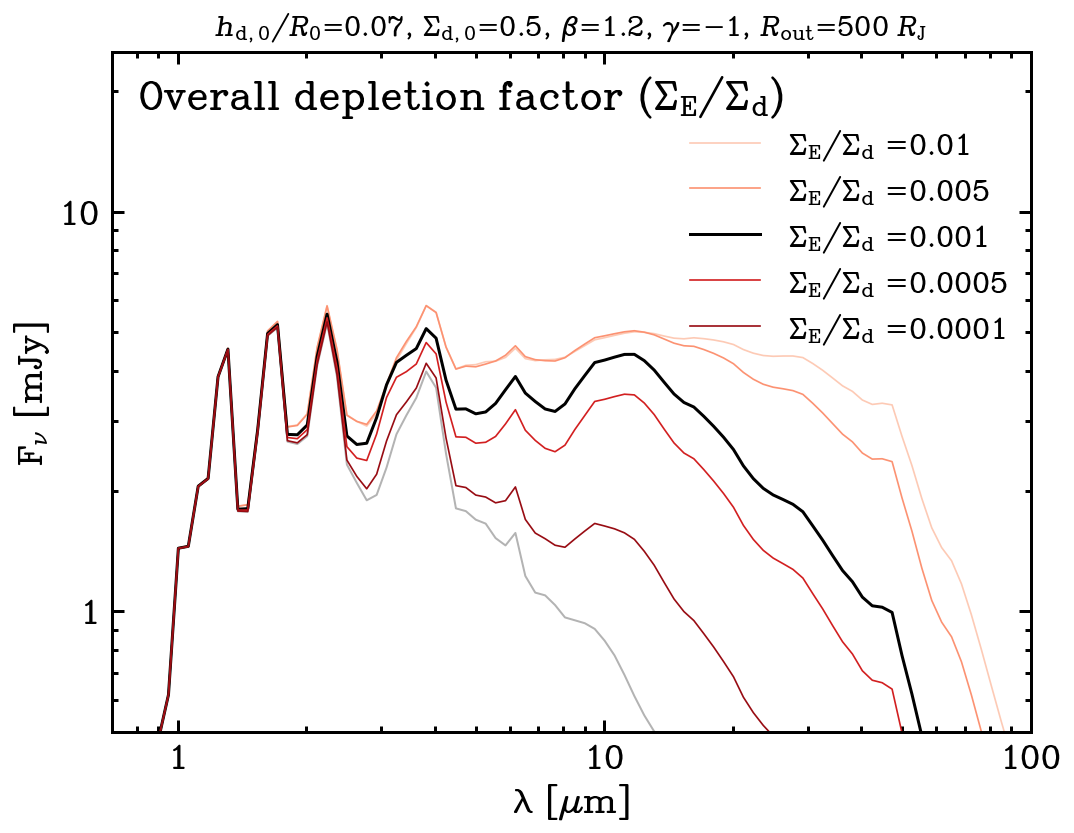

In [9]:
fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(10,8))

dep_list = [1e-2,5e-3,1e-3,5e-4,1e-4]
distance = 50

color_list = plt.cm.Reds(np.linspace(0.2, 0.9, 5))
color_num = 0

ax.plot(x,y/distance**2, color='0.7')

for i in range(0,5):
    if color_num == 2:
        ax.plot(wavelength[:,i],(flux_evo[:,i])/distance**2, label=r'$\Sigma_\mathrm{E}/\Sigma_\mathrm{d}$ ='+str(dep_list[i]), linestyle='-',color='k',linewidth=1.8)
        color_num = color_num + 1
    else:
        ax.plot(wavelength[:,i],(flux_evo[:,i])/distance**2, label=r'$\Sigma_\mathrm{E}/\Sigma_\mathrm{d}$ ='+str(dep_list[i]), linestyle='-',color=color_list[color_num],linewidth=1)
        color_num = color_num + 1

ax.set_title(r'$h_\mathrm{d,0}/R_0$=0.07, $\Sigma_\mathrm{d,0}$=0.5, $\beta$=1.2, $\gamma$=-1, $R_\mathrm{out}$=500 $R_\mathrm{J}$',fontsize= 20)
ax.text(0.8,1.8e-25,r'Overall depletion factor ($\Sigma_\mathrm{E}/\Sigma_\mathrm{d}$)',fontsize=28)

ax.set_xlim(0.7,100)
ax.set_ylim(5e-27,2.5e-25)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlabel(r'$\lambda$ [$\mu$m]',fontsize= 24)
ax.set_ylabel(r"F$_\nu$ [mJy]",fontsize= 24)

ax.set_xticks([1e0,1e1,1e2],[r'1',r'10',r'100'],fontsize= 24)
ax.set_yticks([1e-26,1e-25],[r'1',r'10'],fontsize= 24)

ax.tick_params(axis='both', direction='in', width=1.8, which='major',top=True, right=True)
ax.tick_params(axis='both', direction='in', width=1.8, which='minor',top=True, right=True)
ax.spines['left'].set_linewidth(1.8)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.legend(bbox_to_anchor=(0.58, 0.5),fontsize= 21)

plt.tight_layout(pad=3.0,w_pad=1.0, h_pad=1.0)
plt.show()
